<a href="https://colab.research.google.com/github/KasturiDisale/Info-Viz--HRA-Analyzing-and-Visualizing-Google-Analytics-Data-for-HRA-User-Interfaces/blob/main/Info_Viz_Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

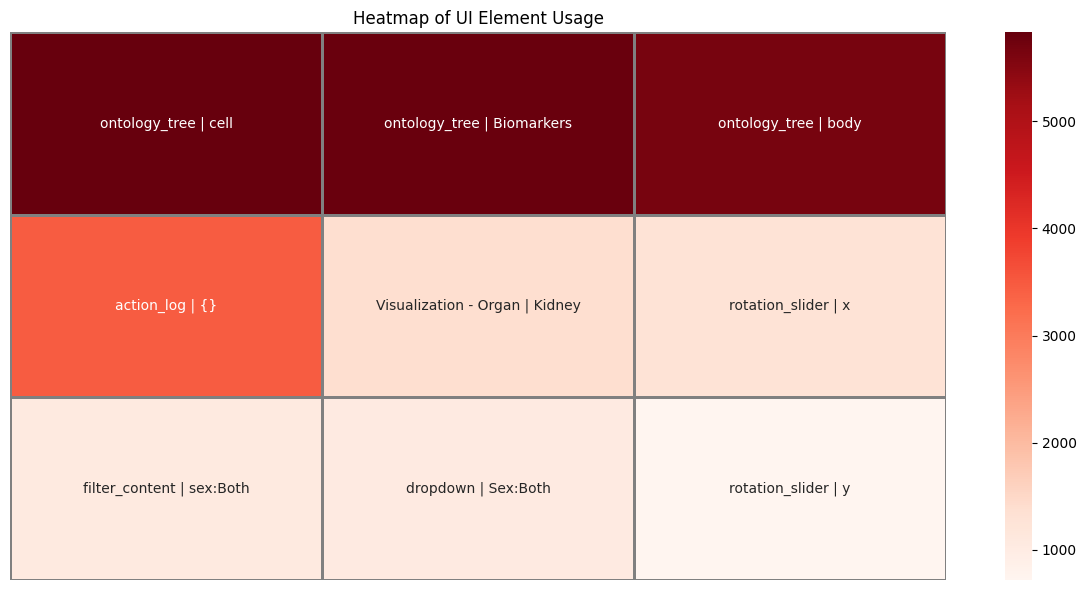

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("/content/20250212-hra-export.csv")

# Drop rows where either event_category or event_label is missing
df = df.dropna(subset=['event_category', 'event_label'])

# Combine event_category and event_label to define unique UI elements
df['ui_element'] = df['event_category'] + ' | ' + df['event_label']

# Count frequency of interactions with each UI element
usage_counts = df['ui_element'].value_counts().reset_index()
usage_counts.columns = ['UI Element', 'Frequency']

# Create a pivot table for a heatmap layout (mocked 2D grid)
top_n = 9
heatmap_data = usage_counts.head(top_n)
grid_size = (3, 3)  # Update this to match top_n layout
heatmap_matrix = heatmap_data['Frequency'].values.reshape(grid_size)
labels = heatmap_data['UI Element'].values.reshape(grid_size)

# Plotting
plt.figure(figsize=(12, 6))
ax = sns.heatmap(heatmap_matrix, annot=labels, fmt='', cmap='Reds', linewidths=1, linecolor='gray')
plt.title('Heatmap of UI Element Usage')
plt.axis('off')
plt.tight_layout()
plt.show()
